<a href="https://colab.research.google.com/github/azrapatvi/Ml_practice/blob/main/11_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df=pd.read_csv('Travel.csv')

In [5]:
df

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0


In [6]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [7]:
df.shape

(4888, 20)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [9]:
df.head(2)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45


In [12]:
cat_cols=[i for i in df.columns if df[i].dtypes=='O']
cat_cols

['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [13]:
num_cols=[i for i in df.columns if df[i].dtypes!='O']
num_cols

['CustomerID',
 'ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [14]:
for i in cat_cols:
  print(i,"- ",df[i].unique())

TypeofContact -  ['Self Enquiry' 'Company Invited' nan]
Occupation -  ['Salaried' 'Free Lancer' 'Small Business' 'Large Business']
Gender -  ['Female' 'Male' 'Fe Male']
ProductPitched -  ['Deluxe' 'Basic' 'Standard' 'Super Deluxe' 'King']
MaritalStatus -  ['Single' 'Divorced' 'Married' 'Unmarried']
Designation -  ['Manager' 'Executive' 'Senior Manager' 'AVP' 'VP']


In [15]:
df['Gender']=df['Gender'].map({
    'Female':'female',
    'Fe Male':'female',
    'Male':'male'
})

In [16]:
df['Gender'].value_counts()

,count
Gender,
male,2916
female,1972


In [17]:
# ['Single' 'Divorced' 'Married' 'Unmarried']

df['MaritalStatus']=df['MaritalStatus'].map({
    'Single':'unmarried',
    'Unmarried':'unmarried',
    'Married':'married',
    'Divorced':'divorced'
})

In [18]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
married,2340
unmarried,1598
divorced,950


In [19]:
for i in cat_cols:
  print(i,"- ",df[i].unique())

TypeofContact -  ['Self Enquiry' 'Company Invited' nan]
Occupation -  ['Salaried' 'Free Lancer' 'Small Business' 'Large Business']
Gender -  ['female' 'male']
ProductPitched -  ['Deluxe' 'Basic' 'Standard' 'Super Deluxe' 'King']
MaritalStatus -  ['unmarried' 'divorced' 'married']
Designation -  ['Manager' 'Executive' 'Senior Manager' 'AVP' 'VP']


In [20]:
df.columns = df.columns.str.lower()

In [21]:
df.isnull().sum()

,0
customerid,0
prodtaken,0
age,226
typeofcontact,25
citytier,0
durationofpitch,251
occupation,0
gender,0
numberofpersonvisiting,0
numberoffollowups,45


In [23]:
df[['age','typeofcontact','durationofpitch','numberoffollowups','preferredpropertystar','numberoftrips','numberofchildrenvisiting','monthlyincome']].select_dtypes(exclude='object').describe()

,age,durationofpitch,numberoffollowups,preferredpropertystar,numberoftrips,numberofchildrenvisiting,monthlyincome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


age


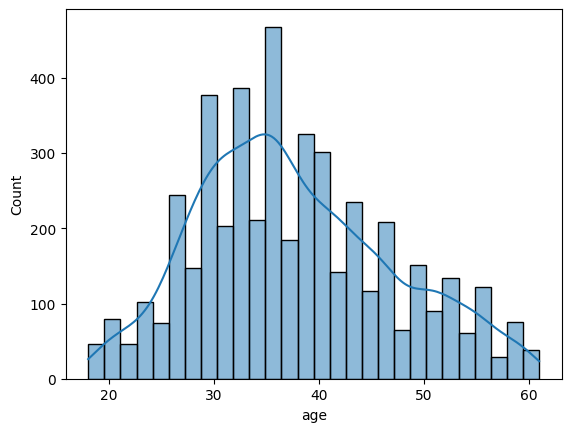

typeofcontact


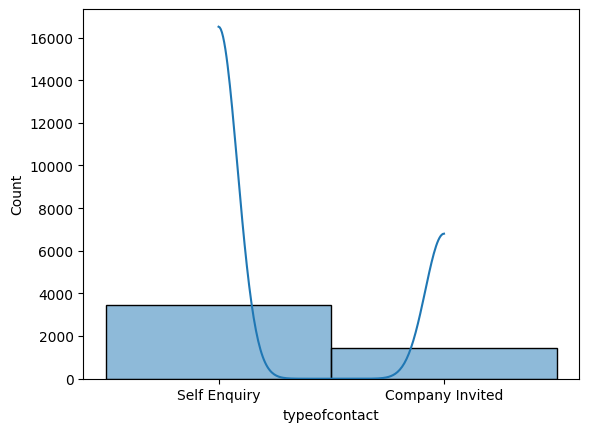

durationofpitch


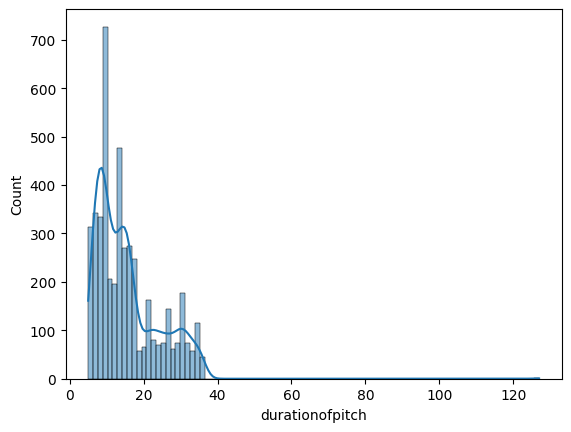

numberoffollowups


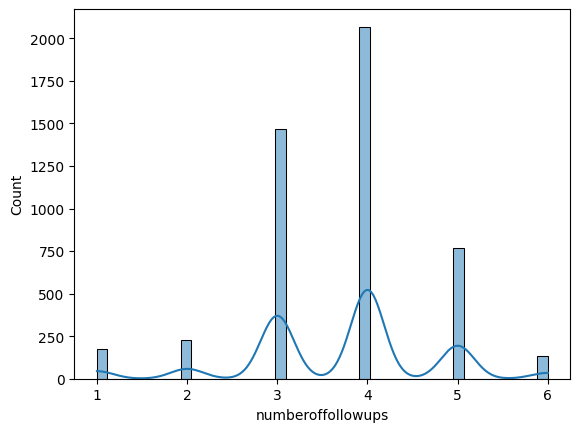

preferredpropertystar


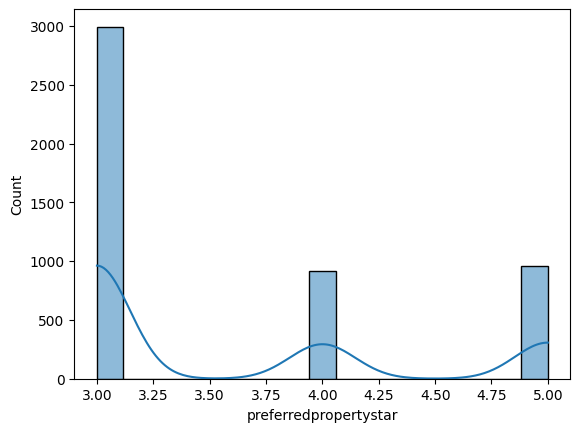

numberoftrips


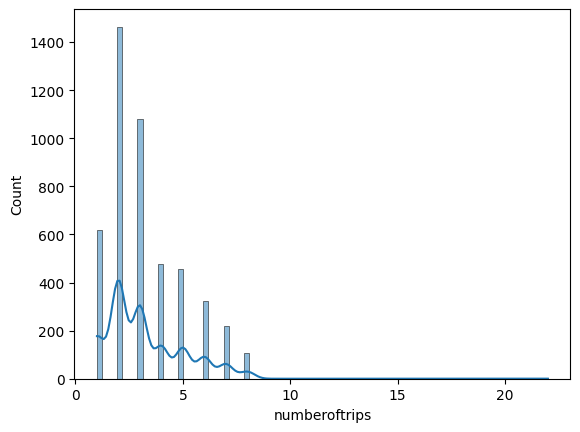

numberofchildrenvisiting


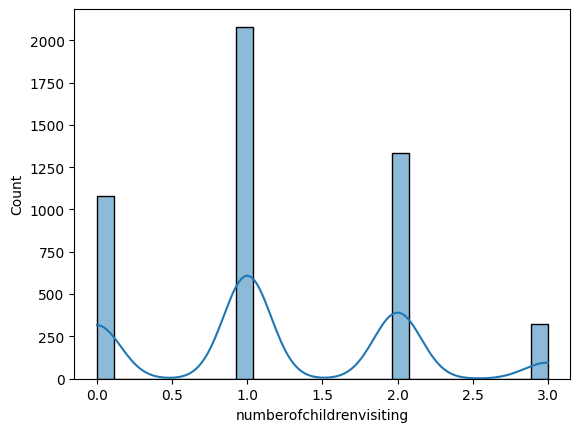

monthlyincome


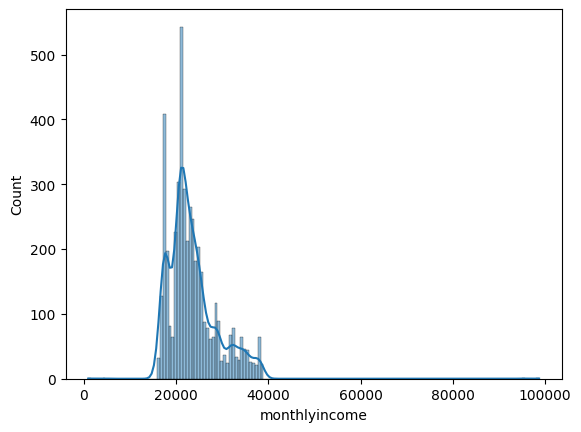

In [25]:
features_with_na=['age','typeofcontact','durationofpitch','numberoffollowups','preferredpropertystar','numberoftrips','numberofchildrenvisiting','monthlyincome']

for i in features_with_na:
  print(i)
  sns.histplot(df[i],kde=True)
  plt.show()

In [28]:
for i in df[features_with_na].select_dtypes(exclude='object'):
  print(i,"- ",df[i].skew())

age -  0.38298868373855377
durationofpitch -  1.7520370490349106
numberoffollowups -  -0.37271939892913725
preferredpropertystar -  0.8955450954235519
numberoftrips -  1.4538837843258117
numberofchildrenvisiting -  0.2721993315693236
monthlyincome -  1.949159831766865


```
| Column                     | Skewness | Distribution      | Fill NaN with |
| -------------------------- | -------: | ----------------- | ------------- |
| `Age`                      |    0.383 | Roughly symmetric | **Mean**      |
| `DurationOfPitch`          |    1.752 | Right-skewed      | **Median**    |
| `NumberOfFollowups`        |   -0.373 | Roughly symmetric | **Mean**      |
| `PreferredPropertyStar`    |    0.896 | Right-skewed      | **Median**    |
| `NumberOfTrips`            |    1.454 | Right-skewed      | **Median**    |
| `NumberOfChildrenVisiting` |    0.272 | Roughly symmetric | **Mean**      |
| `MonthlyIncome`            |    1.949 | Right-skewed      | **Median**    |

```

In [29]:
for i in df[features_with_na].select_dtypes(include='object'):
  print(i)

typeofcontact


In [31]:
features_with_na_cat_col=[i for i in df[features_with_na].select_dtypes(include='object')]
features_with_na_num_col=[i for i in df[features_with_na].select_dtypes(exclude='object')]

In [32]:
features_with_na_cat_col

['typeofcontact']

In [33]:
features_with_na_num_col


['age',
 'durationofpitch',
 'numberoffollowups',
 'preferredpropertystar',
 'numberoftrips',
 'numberofchildrenvisiting',
 'monthlyincome']

In [35]:
df['age'] = df['age'].fillna(df['age'].mean())

df['durationofpitch'] = df['durationofpitch'].fillna(df['durationofpitch'].median())

df['numberoffollowups'] = df['numberoffollowups'].fillna(df['numberoffollowups'].mean())

df['preferredpropertystar'] = df['preferredpropertystar'].fillna(df['preferredpropertystar'].median())

df['numberoftrips'] = df['numberoftrips'].fillna(df['numberoftrips'].median())

df['numberofchildrenvisiting'] = df['numberofchildrenvisiting'].fillna(df['numberofchildrenvisiting'].mean())

df['monthlyincome'] = df['monthlyincome'].fillna(df['monthlyincome'].median())

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customerid                4888 non-null   int64  
 1   prodtaken                 4888 non-null   int64  
 2   age                       4888 non-null   float64
 3   typeofcontact             4863 non-null   object 
 4   citytier                  4888 non-null   int64  
 5   durationofpitch           4888 non-null   float64
 6   occupation                4888 non-null   object 
 7   gender                    4888 non-null   object 
 8   numberofpersonvisiting    4888 non-null   int64  
 9   numberoffollowups         4888 non-null   float64
 10  productpitched            4888 non-null   object 
 11  preferredpropertystar     4888 non-null   float64
 12  maritalstatus             4888 non-null   object 
 13  numberoftrips             4888 non-null   float64
 14  passport

In [37]:
df.isnull().sum()

,0
customerid,0
prodtaken,0
age,0
typeofcontact,25
citytier,0
durationofpitch,0
occupation,0
gender,0
numberofpersonvisiting,0
numberoffollowups,0


In [38]:
df['typeofcontact']=df['typeofcontact'].fillna(df['typeofcontact'].mode()[0])

In [39]:
df.isnull().sum()

,0
customerid,0
prodtaken,0
age,0
typeofcontact,0
citytier,0
durationofpitch,0
occupation,0
gender,0
numberofpersonvisiting,0
numberoffollowups,0


In [41]:
df.drop('customerid',axis=1,inplace=True)

In [42]:
df.head(2)

,prodtaken,age,typeofcontact,citytier,durationofpitch,occupation,gender,numberofpersonvisiting,numberoffollowups,productpitched,preferredpropertystar,maritalstatus,numberoftrips,passport,pitchsatisfactionscore,owncar,numberofchildrenvisiting,designation,monthlyincome
0,1,41.0,Self Enquiry,3,6.0,Salaried,female,3,3.0,Deluxe,3.0,unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,male,3,4.0,Deluxe,4.0,divorced,2.0,0,3,1,2.0,Manager,20130.0


In [43]:
df['total_person_visiting']=df['numberofchildrenvisiting']+df['numberofpersonvisiting']

df.drop(['numberofchildrenvisiting','numberofpersonvisiting'],axis=1,inplace=True)

In [44]:
df.head()

,prodtaken,age,typeofcontact,citytier,durationofpitch,occupation,gender,numberoffollowups,productpitched,preferredpropertystar,maritalstatus,numberoftrips,passport,pitchsatisfactionscore,owncar,designation,monthlyincome,total_person_visiting
0,1,41.000000,Self Enquiry,3,6.0,Salaried,female,3.0,Deluxe,3.0,unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.000000,Company Invited,1,14.0,Salaried,male,4.0,Deluxe,4.0,divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.000000,Self Enquiry,1,8.0,Free Lancer,male,4.0,Basic,3.0,unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.000000,Company Invited,1,9.0,Salaried,female,3.0,Basic,3.0,divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,37.622265,Self Enquiry,1,8.0,Small Business,male,3.0,Basic,4.0,divorced,1.0,0,5,1,Executive,18468.0,2.0


In [45]:
df.shape

(4888, 18)

In [46]:
X=df.drop('prodtaken',axis=1)
y=df['prodtaken']

In [47]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [48]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    random_state=42
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [52]:
cat_cols=[i for i in X.columns if X[i].dtypes=='object']
num_cols=[i for i in X.columns if X[i].dtypes!='object']

In [53]:
cat_cols

['typeofcontact',
 'occupation',
 'gender',
 'productpitched',
 'maritalstatus',
 'designation']

In [54]:
for i in cat_cols:
  print(i, "- ",df[i].unique())

typeofcontact -  ['Self Enquiry' 'Company Invited']
occupation -  ['Salaried' 'Free Lancer' 'Small Business' 'Large Business']
gender -  ['female' 'male']
productpitched -  ['Deluxe' 'Basic' 'Standard' 'Super Deluxe' 'King']
maritalstatus -  ['unmarried' 'divorced' 'married']
designation -  ['Manager' 'Executive' 'Senior Manager' 'AVP' 'VP']


In [55]:
X['gender']=X['gender'].map({
    "female":1,
    "male":0
})

In [50]:
X.head(2)

,age,typeofcontact,citytier,durationofpitch,occupation,gender,numberoffollowups,productpitched,preferredpropertystar,maritalstatus,numberoftrips,passport,pitchsatisfactionscore,owncar,designation,monthlyincome,total_person_visiting
0,41.0,Self Enquiry,3,6.0,Salaried,female,3.0,Deluxe,3.0,unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,male,4.0,Deluxe,4.0,divorced,2.0,0,3,1,Manager,20130.0,5.0


In [56]:
num_cols


['age',
 'citytier',
 'durationofpitch',
 'numberoffollowups',
 'preferredpropertystar',
 'numberoftrips',
 'passport',
 'pitchsatisfactionscore',
 'owncar',
 'monthlyincome',
 'total_person_visiting']

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [58]:
from sklearn.pipeline import Pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [59]:
from sklearn.metrics import accuracy_score


In [60]:
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9212678936605317
